In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Cargar los CSVs limpios desde processed
processed_path = 'data/processed/'

orders = pd.read_csv(processed_path + 'orders_clean.csv')
order_items = pd.read_csv(processed_path + 'order_items_clean.csv')
customers = pd.read_csv(processed_path + 'customers_clean.csv')
products = pd.read_csv(processed_path + 'products_clean.csv')
sellers = pd.read_csv(processed_path + 'sellers_clean.csv')
payments = pd.read_csv(processed_path + 'order_payments_clean.csv')
reviews = pd.read_csv(processed_path + 'order_reviews_clean.csv')
# geolocation no la usaremos en EDA inicial (opcional más adelante)

# Convertir fechas nuevamente (por si se perdieron al guardar CSV)
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')

print("Datos cargados correctamente")
print(f"Pedidos: {orders.shape}")
print(f"Items: {order_items.shape}")
print(f"Pagos: {payments.shape}")

Datos cargados correctamente
Pedidos: (99441, 8)
Items: (112650, 7)
Pagos: (103886, 5)


In [2]:
# Fusionamos órdenes con items y productos
# Esto nos permitirá responder preguntas de ventas y logística
orders_items = orders.merge(order_items, on='order_id', how='inner')
orders_items_prod = orders_items.merge(products, on='product_id', how='left')

# Agregamos pagos por cada order_id (un pedido puede tener varios métodos de pago, sumamos)
payments_sum = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max',  # número máximo de cuotas
    'payment_type': lambda x: ', '.join(x.unique())  # lista de métodos usados
}).reset_index()

# Unir pagos al dataframe principal
df_full = orders_items_prod.merge(payments_sum, on='order_id', how='left')

# Agregamos reseñas
df_full = df_full.merge(reviews[['order_id', 'review_score']].drop_duplicates('order_id'), on='order_id', how='left')

# Creamos columna mes-año para análisis temporal
df_full['year_month'] = df_full['order_purchase_timestamp'].dt.to_period('M')

print(f"Dataframe consolidado: {df_full.shape}")
df_full.head(2)

Dataframe consolidado: (112650, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_value,payment_installments,payment_type,review_score,year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,4.0,500.0,19.0,8.0,13.0,38.71,1.0,"credit_card, voucher",4.0,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,1.0,400.0,19.0,13.0,19.0,141.46,1.0,boleto,4.0,2018-07


In [3]:
# Ventas diarias (precio + flete? o solo precio? Usamos price)
daily_sales = df_full.groupby(df_full['order_purchase_timestamp'].dt.date)['price'].sum().reset_index()
daily_sales.columns = ['date', 'sales']

fig = px.line(daily_sales, x='date', y='sales', 
              title='Evolución diaria de ventas (precio de productos)',
              labels={'date': 'Fecha', 'sales': 'Ventas (R$)'})
fig.update_layout(xaxis_title='Fecha', yaxis_title='Ventas (R$)')
fig.show()

# Mensual
monthly_sales = df_full.groupby('year_month')['price'].sum().reset_index()
monthly_sales['year_month_str'] = monthly_sales['year_month'].astype(str)

fig2 = px.bar(monthly_sales, x='year_month_str', y='price',
              title='Ventas mensuales',
              labels={'year_month_str': 'Mes', 'price': 'Ventas (R$)'})
fig2.show()

In [7]:
import nbformat
print(nbformat.__version__)

5.10.4


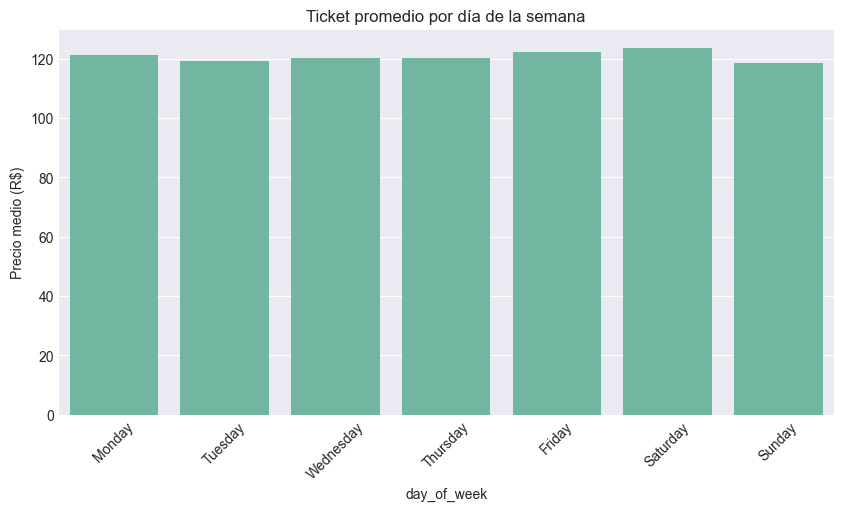

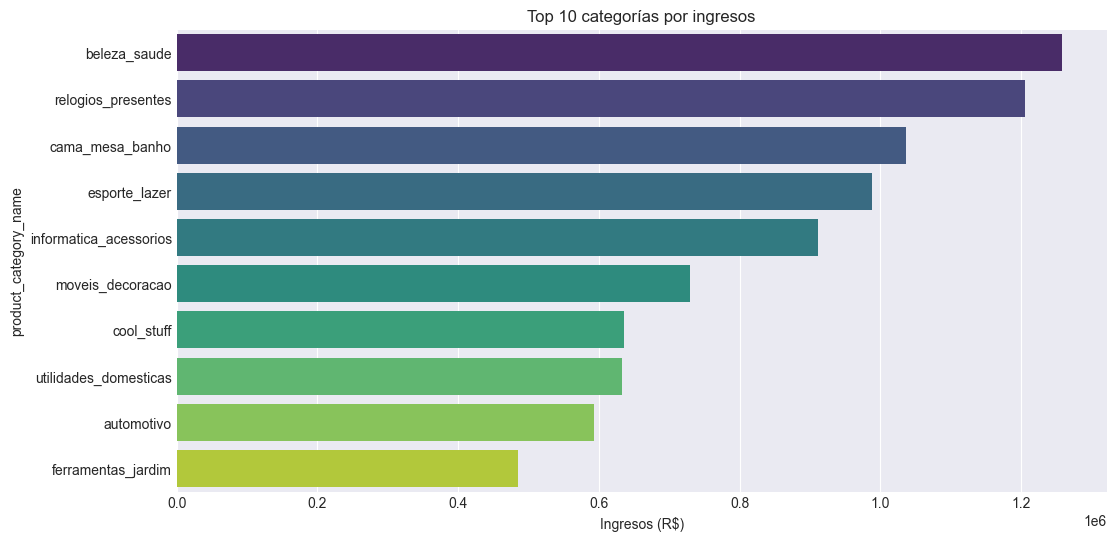

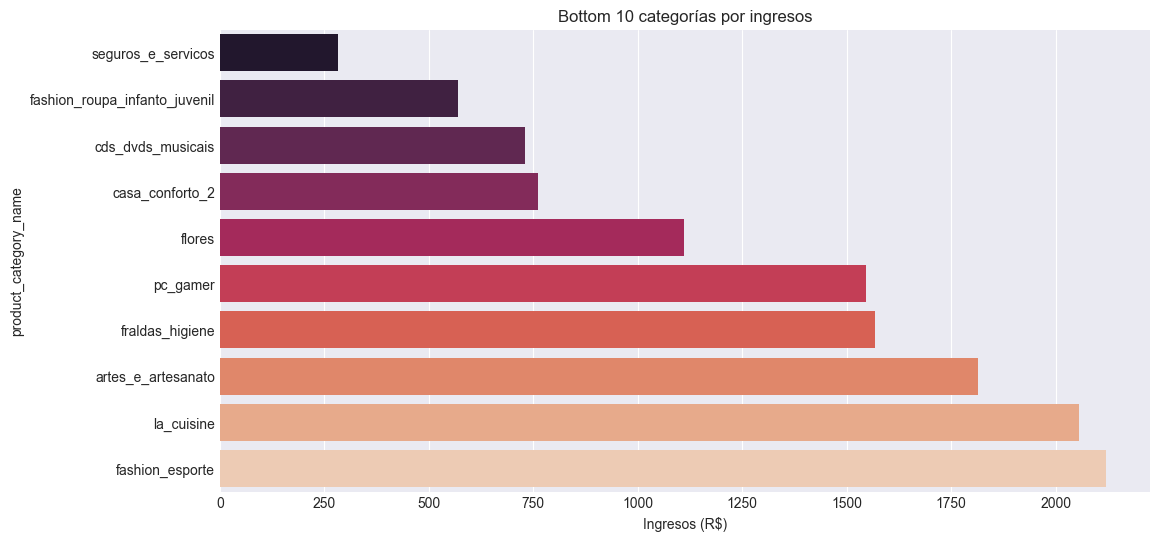

In [4]:
# Ventas por día de la semana
df_full['day_of_week'] = df_full['order_purchase_timestamp'].dt.day_name()
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = df_full.groupby('day_of_week')['price'].mean().reindex(week_order)

plt.figure(figsize=(10,5))
sns.barplot(x=daily_avg.index, y=daily_avg.values)
plt.title('Ticket promedio por día de la semana')
plt.ylabel('Precio medio (R$)')
plt.xticks(rotation=45)
plt.show()

# Top 10 categorías por ingresos
# Nota: product_category_name puede venir en portugués, usamos la traducción si la tenemos
# Si no, usamos la columna original
categoria_ventas = df_full.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=categoria_ventas.values, y=categoria_ventas.index, palette='viridis')
plt.title('Top 10 categorías por ingresos')
plt.xlabel('Ingresos (R$)')
plt.show()

# Bottom 10
bottom = df_full.groupby('product_category_name')['price'].sum().sort_values().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=bottom.values, y=bottom.index, palette='rocket')
plt.title('Bottom 10 categorías por ingresos')
plt.xlabel('Ingresos (R$)')
plt.show()

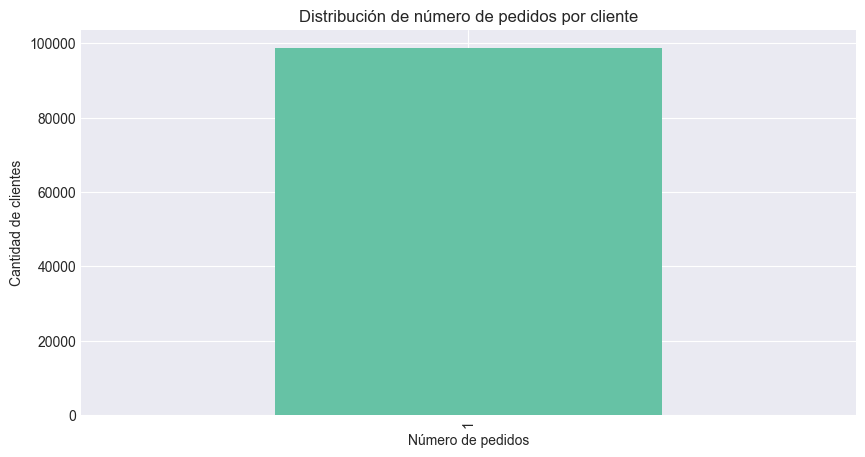

Clientes recurrentes: 0 (0.00%)


In [5]:
# Número de pedidos por cliente
customer_orders = df_full.groupby('customer_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_id', 'num_orders']

# Distribución
plt.figure(figsize=(10,5))
customer_orders['num_orders'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de número de pedidos por cliente')
plt.xlabel('Número de pedidos')
plt.ylabel('Cantidad de clientes')
plt.show()

# Porcentaje de clientes recurrentes (más de 1 pedido)
recurrent = (customer_orders['num_orders'] > 1).sum()
total_cust = len(customer_orders)
print(f"Clientes recurrentes: {recurrent} ({recurrent/total_cust*100:.2f}%)")

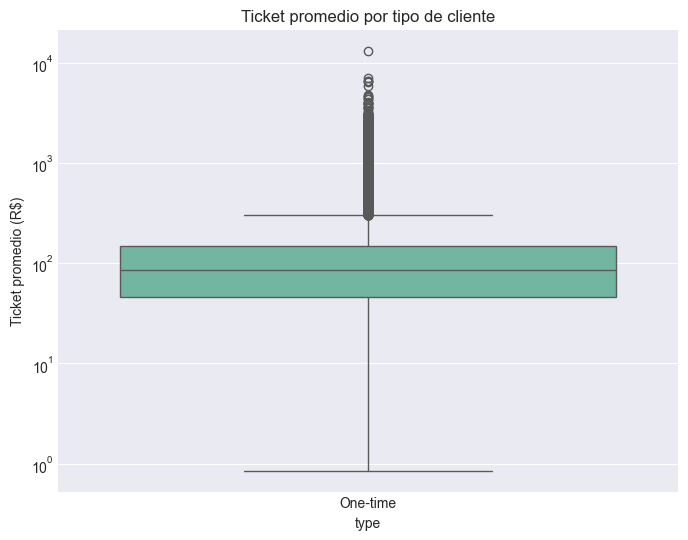

In [6]:
# Unimos ticket promedio por pedido, luego por cliente
order_ticket = df_full.groupby('order_id')['price'].sum().reset_index()
order_ticket.columns = ['order_id', 'order_total']
customer_ticket = df_full[['customer_id','order_id']].drop_duplicates().merge(order_ticket, on='order_id')
customer_avg_ticket = customer_ticket.groupby('customer_id')['order_total'].mean().reset_index()

# Fusionamos con frecuencia
customer_profile = customer_orders.merge(customer_avg_ticket, on='customer_id')
customer_profile['type'] = np.where(customer_profile['num_orders'] == 1, 'One-time', 'Recurrent')

plt.figure(figsize=(8,6))
sns.boxplot(x='type', y='order_total', data=customer_profile)
plt.title('Ticket promedio por tipo de cliente')
plt.ylabel('Ticket promedio (R$)')
plt.yscale('log')  # escala log para mejor visualización
plt.show()

## Sección 3: Logística


In [7]:
# Calcular días de entrega real y estimado
df_delivery = orders.dropna(subset=['order_delivered_customer_date']).copy()
df_delivery['delivery_days'] = (df_delivery['order_delivered_customer_date'] - df_delivery['order_purchase_timestamp']).dt.days
df_delivery['estimated_days'] = (df_delivery['order_estimated_delivery_date'] - df_delivery['order_purchase_timestamp']).dt.days
df_delivery['delay_days'] = df_delivery['delivery_days'] - df_delivery['estimated_days']

# Estadísticas
print("Estadísticas de tiempo de entrega (días):")
print(df_delivery['delivery_days'].describe())
print("\nEstadísticas de retraso (días positivos = retraso):")
print(df_delivery['delay_days'].describe())

# Porcentaje de pedidos con retraso (>0 días)
delay_rate = (df_delivery['delay_days'] > 0).mean()
print(f"\nPorcentaje de pedidos con retraso: {delay_rate*100:.2f}%")

Estadísticas de tiempo de entrega (días):
count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

Estadísticas de retraso (días positivos = retraso):
count    96476.000000
mean       -11.280142
std         10.193898
min       -146.000000
25%        -16.000000
50%        -12.000000
75%         -7.000000
max        189.000000
Name: delay_days, dtype: float64

Porcentaje de pedidos con retraso: 7.57%


In [13]:
print(customers.head(2))

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  


Filas sin estado: 0


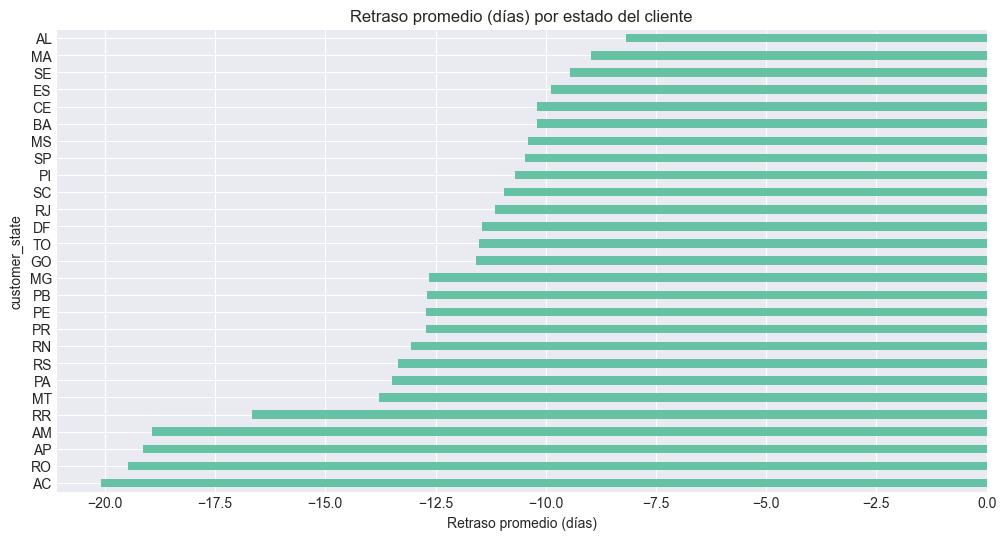

In [15]:
# Necesitamos unir con customers para obtener el estado del cliente
customers_state = customers[['customer_id', 'customer_state']]
# df_delivery ya tiene customer_id (porque vino de orders)
df_with_state = df_delivery.merge(customers_state, on='customer_id', how='left')

# Verificar que no haya nulos en customer_state (por si acaso)
print(f"Filas sin estado: {df_with_state['customer_state'].isnull().sum()}")
state_delay = df_with_state.groupby('customer_state')['delay_days'].mean().sort_values()

plt.figure(figsize=(12,6))
state_delay.plot(kind='barh')
plt.title('Retraso promedio (días) por estado del cliente')
plt.xlabel('Retraso promedio (días)')
plt.show()

## Sección 4: Pagos

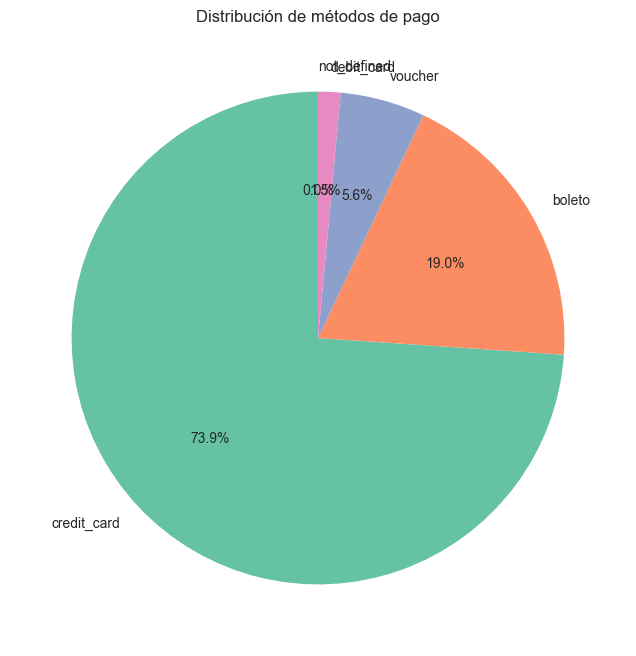

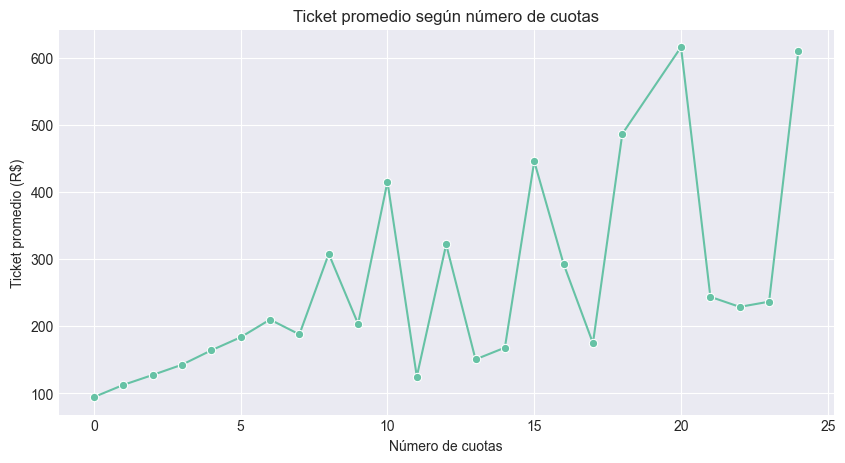

In [16]:
# Distribución de métodos de pago
payment_methods = payments['payment_type'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(payment_methods.values, labels=payment_methods.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de métodos de pago')
plt.show()

# Ticket promedio por número de cuotas
installment_ticket = payments.groupby('payment_installments')['payment_value'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=installment_ticket, x='payment_installments', y='payment_value', marker='o')
plt.title('Ticket promedio según número de cuotas')
plt.xlabel('Número de cuotas')
plt.ylabel('Ticket promedio (R$)')
plt.show()

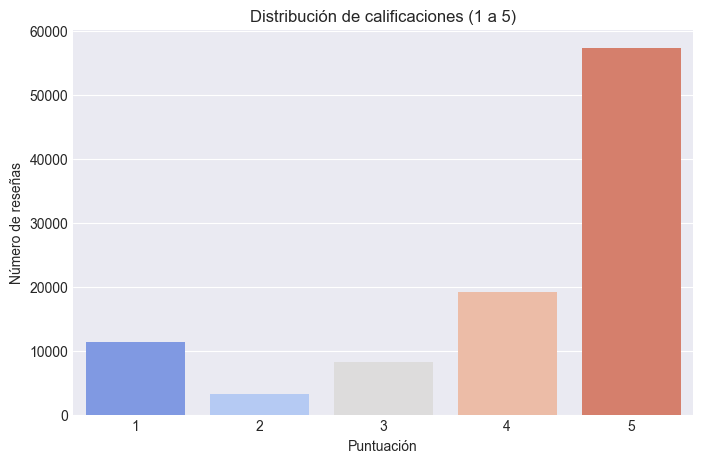

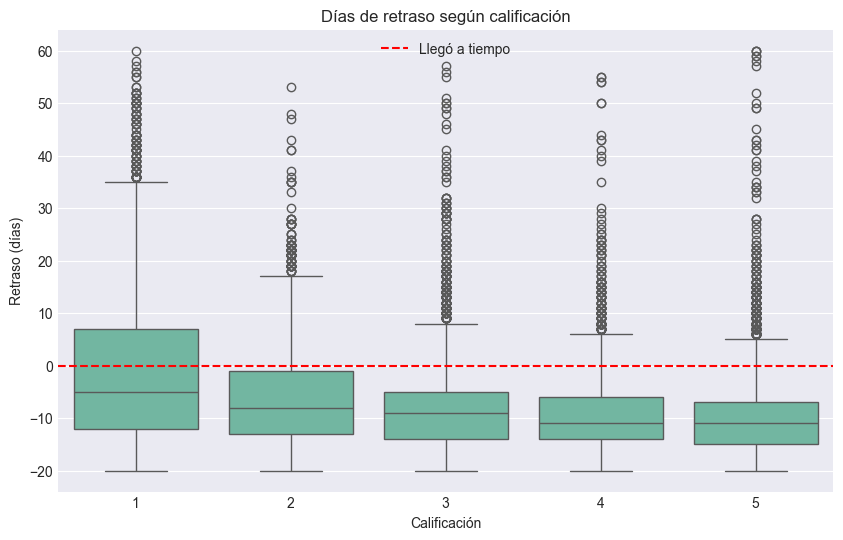

In [11]:
# Distribución de scores
score_dist = reviews['review_score'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=score_dist.index, y=score_dist.values, palette='coolwarm')
plt.title('Distribución de calificaciones (1 a 5)')
plt.xlabel('Puntuación')
plt.ylabel('Número de reseñas')
plt.show()

# Relación retraso vs calificación (unir con df_delivery)
reviews_delivery = reviews.merge(df_delivery[['order_id','delay_days']], on='order_id', how='inner')
# Eliminar valores extremos de retraso para mejor visualización
reviews_delivery = reviews_delivery[reviews_delivery['delay_days'].between(-20, 60)]

plt.figure(figsize=(10,6))
sns.boxplot(x='review_score', y='delay_days', data=reviews_delivery)
plt.title('Días de retraso según calificación')
plt.xlabel('Calificación')
plt.ylabel('Retraso (días)')
plt.axhline(y=0, color='r', linestyle='--', label='Llegó a tiempo')
plt.legend()
plt.show()

In [12]:
# Calcular correlación
corr = reviews_delivery[['review_score','delay_days']].corr().iloc[0,1]
print(f"Correlación entre retraso (días) y calificación: {corr:.3f}")
print("(Negativo: más retraso → peor calificación, como se esperaba)")

Correlación entre retraso (días) y calificación: -0.348
(Negativo: más retraso → peor calificación, como se esperaba)


In [17]:
# Exportar algunos agregados que usaremos en SQL y Power BI
# Por ejemplo, ventas mensuales por categoría, tiempos de entrega por estado, etc.
monthly_sales_cat = df_full.groupby(['year_month', 'product_category_name'])['price'].sum().reset_index()
monthly_sales_cat.to_csv('data/processed/monthly_sales_by_category.csv', index=False)

delivery_by_state = df_with_state.groupby('customer_state').agg({
    'delivery_days': 'mean',
    'delay_days': 'mean',
    'order_id': 'count'
}).rename(columns={'order_id': 'num_orders'}).reset_index()
delivery_by_state.to_csv('data/processed/delivery_by_state.csv', index=False)

print("Archivos intermedios guardados para Fase 3 y 4.")

Archivos intermedios guardados para Fase 3 y 4.
